# Lecture 6 — Measuring Performance and Regularization
## Lab Notebook · Deep Learning · UCU — **Solution**

In Notebook 4, we tuned the *training dynamics* — loss, optimizer, initialization, batch size, schedule — on FashionMNIST. We held the dataset fixed and trained until the optimizer converged. In this notebook, we step back and ask: *when should we stop, and what should we change so the model generalizes?* We also switch to a new problem — **UCI Covertype**, predicting forest cover type from cartographic features — where regularization pays off.

### By the end of this notebook, you will:

1. Build a proper train / validation / test split in PyTorch, including stratified splits and per-class diagnostics.
2. Tune hyperparameters with `sklearn.model_selection.ParameterGrid` and with **Optuna**.
3. Compare regularization techniques — weight decay (AdamW), dropout, label smoothing, early stopping — under a fair protocol.
4. Use learning-rate schedulers (`StepLR`, `CosineAnnealingLR`, `ReduceLROnPlateau`) and pick the right one for the situation.
5. *(Optional)* Observe **double descent** — test error as a function of model width, past the interpolation threshold.

> **Note.** Data augmentation belongs naturally to image data; we will meet it in Notebook 6 when we introduce CNNs.

### Recurring practical recommendations

- **Hidden dimensions as powers of two** (32, 64, 128, 256, 512, …).
- **Read the docs** before choosing hyperparameters.
- **Log-scale for hyperparameters that span orders of magnitude**; **linear scale for bounded quantities**.
- **If the best value lands on the edge of the search space, extend the search** in that direction.


## Setup

In [1]:
# !pip install -q optuna torchinfo

import copy
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset, random_split

import sklearn
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import optuna
from torchinfo import summary

warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

C1, C2, C3, C4 = "#19326E", "#50ACB0", "#CD742A", "#A3477F"
C5, C6, C7     = "#907FAB", "#4294CC", "#89A943"
UCU_COLORS = [C1, C2, C3, C4, C5, C6, C7]


Using device: cpu


/Users/gonza/personal/UCU-DL/deep-learning-course/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## Section 1 — Train / Validation / Test the PyTorch Way

### Exercise 1.1 — Load and inspect the dataset

In [2]:
# SOLUTION
data = fetch_covtype(as_frame=False)
X = data.data.astype(np.float32)
y = data.target.astype(np.int64) - 1  # remap 1..7 -> 0..6

print("X shape:", X.shape, "| y shape:", y.shape)
print("Classes:", np.unique(y, return_counts=True))


X shape: (581012, 54) | y shape: (581012,)
Classes: (array([0, 1, 2, 3, 4, 5, 6]), array([211840, 283301,  35754,   2747,   9493,  17367,  20510]))


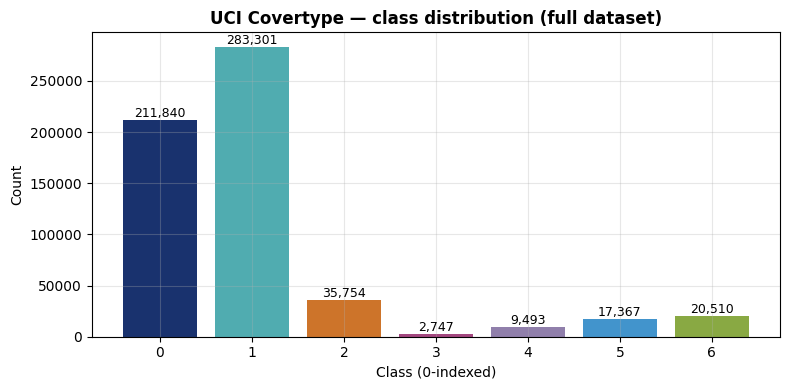

In [3]:
classes, counts = np.unique(y, return_counts=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(classes, counts, color=UCU_COLORS)
ax.set_xlabel("Class (0-indexed)")
ax.set_ylabel("Count")
ax.set_title("UCI Covertype — class distribution (full dataset)",
             fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
for c, n in zip(classes, counts):
    ax.text(c, n, f"{n:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()


### Exercise 1.2 — Stratified subsample to 30 000 examples

Pool shapes: (30000, 54) (30000,)


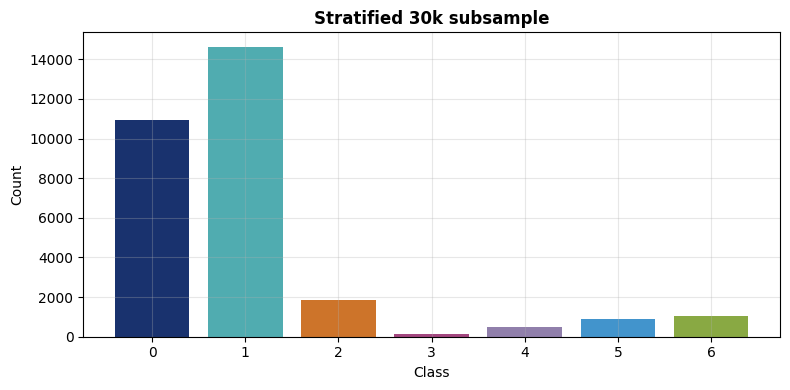

In [4]:
# SOLUTION
X_pool, _, y_pool, _ = train_test_split(
    X, y, train_size=30000, stratify=y, random_state=SEED
)

print("Pool shapes:", X_pool.shape, y_pool.shape)

classes_p, counts_p = np.unique(y_pool, return_counts=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(classes_p, counts_p, color=UCU_COLORS)
ax.set_xlabel("Class"); ax.set_ylabel("Count")
ax.set_title("Stratified 30k subsample", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### Exercise 1.3 — Three-way split with `random_split` (first attempt)

In [5]:
# SOLUTION
X_pool_t = torch.tensor(X_pool, dtype=torch.float32)
y_pool_t = torch.tensor(y_pool, dtype=torch.long)
full_ds = TensorDataset(X_pool_t, y_pool_t)

gen = torch.Generator().manual_seed(SEED)
train_ds_rand, val_ds_rand, test_ds_rand = random_split(
    full_ds, [21000, 3000, 6000], generator=gen
)

print(len(train_ds_rand), len(val_ds_rand), len(test_ds_rand))


21000 3000 6000


### Exercise 1.4 — Inspect the class distribution of each split

In [6]:
def class_counts(subset, num_classes=7):
    # SOLUTION
    counts = torch.zeros(num_classes, dtype=torch.long)
    for _, y in subset:
        counts[int(y)] += 1
    return counts


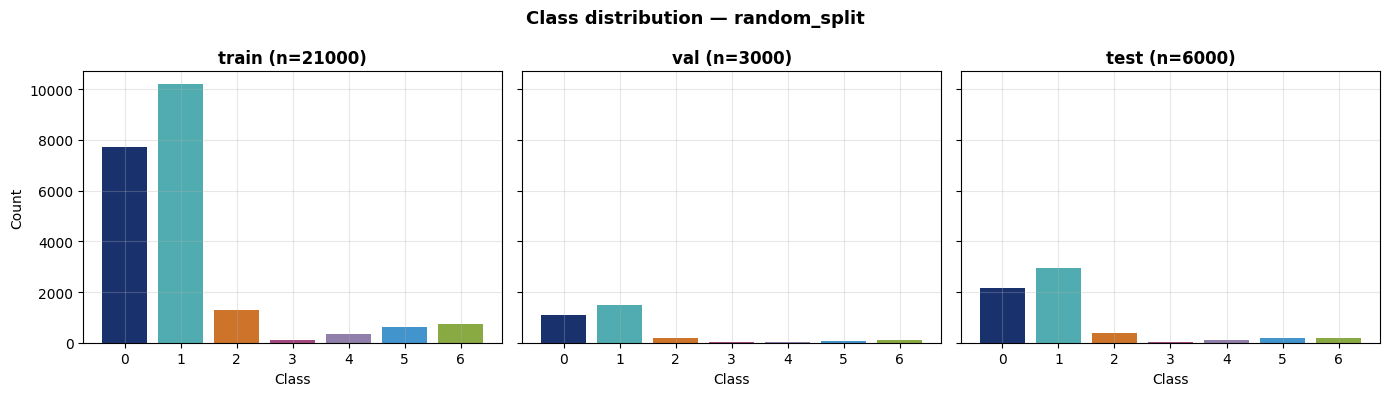

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, ds, name in zip(axes,
                        [train_ds_rand, val_ds_rand, test_ds_rand],
                        ["train", "val", "test"]):
    c = class_counts(ds).numpy()
    ax.bar(range(len(c)), c, color=UCU_COLORS)
    ax.set_title(f"{name} (n={len(ds)})", fontweight="bold")
    ax.set_xlabel("Class"); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Count")
plt.suptitle("Class distribution — random_split", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


> **Question 1.1** — Compare your three plots. Did `random_split` preserve the class ratios? Look at the rarest class — are there enough samples in the validation set to estimate its accuracy reliably?

**Answer.** The ratios are *approximately* preserved (30 000 samples is large enough that uniform random draws track the population). But the rarest class (class 3, ~0.5% of the pool, ~14 samples expected in a 3 000-sample validation set) is so sparse that estimating its accuracy is very noisy: a handful of flips moves the per-class metric by several percentage points. With `random_split` there is also a non-trivial chance of landing far from the expected 14 samples. That is why stratification matters — we want the rare-class count to be *exactly* proportional, not *roughly* so.


### Exercise 1.5 — Stratified three-way split

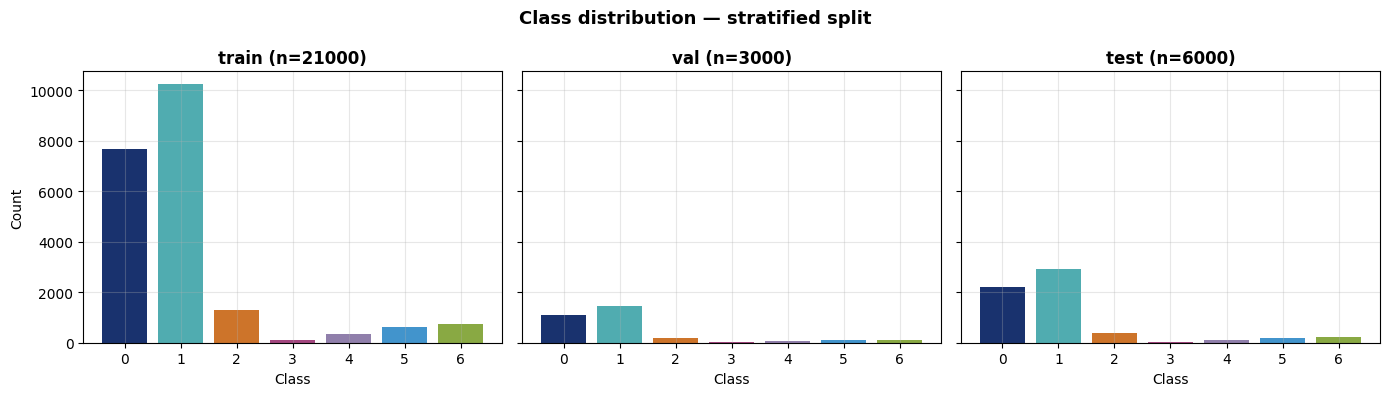

In [8]:
# SOLUTION
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_pool, y_pool, test_size=6000, stratify=y_pool, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=3000, stratify=y_trainval, random_state=SEED
)

def to_ds(Xa, ya):
    return TensorDataset(torch.tensor(Xa, dtype=torch.float32),
                         torch.tensor(ya, dtype=torch.long))

train_ds = to_ds(X_train, y_train)
val_ds   = to_ds(X_val,   y_val)
test_ds  = to_ds(X_test,  y_test)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, ds, name in zip(axes, [train_ds, val_ds, test_ds],
                        ["train", "val", "test"]):
    c = class_counts(ds).numpy()
    ax.bar(range(len(c)), c, color=UCU_COLORS)
    ax.set_title(f"{name} (n={len(ds)})", fontweight="bold")
    ax.set_xlabel("Class"); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Count")
plt.suptitle("Class distribution — stratified split", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


> **Question 1.2** — Why does stratification matter *more* for Covertype than it did for FashionMNIST? What would happen if the rare class ended up entirely in one split?

**Answer.** FashionMNIST is perfectly balanced (10 % per class) — random sampling works fine. Covertype is heavily imbalanced: class 2 is ~49 %, class 3 is ~0.5 %. A random split can easily put an unlucky fraction of the rare class into one of the three partitions. In the worst case, if the entire rare class landed in the test set, the model would never see it during training and would be guaranteed 0 % accuracy on that class at test time — an artefact of the split, not of the model. Stratification guarantees every class appears in every split in the same proportion.


### Exercise 1.6 — Standardize features without leakage

In [9]:
# SOLUTION
scaler = StandardScaler().fit(X_train)  # fit on train ONLY
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

train_ds = to_ds(X_train_s, y_train)
val_ds   = to_ds(X_val_s,   y_val)
test_ds  = to_ds(X_test_s,  y_test)

X_tr_scaled = train_ds.tensors[0].numpy()
print("Train mean (should be ~0):", X_tr_scaled.mean(axis=0)[:5])
print("Train std  (should be ~1):", X_tr_scaled.std(axis=0)[:5])


Train mean (should be ~0): [-1.9489867e-07 -4.1113012e-08 -2.5919505e-08 -1.7208997e-07
 -1.5014693e-08]
Train std  (should be ~1): [0.999999  1.0000093 0.9999938 0.9999835 0.9999885]


### Exercise 1.7 — Build the `DataLoader`s

In [10]:
# SOLUTION
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)

x_batch, y_batch = next(iter(train_loader))
print("Batch X:", x_batch.shape, x_batch.dtype)
print("Batch y:", y_batch.shape, y_batch.dtype)


Batch X: torch.Size([256, 54]) torch.float32
Batch y: torch.Size([256]) torch.int64


> **Question 1.3** — Why does only the training loader use `shuffle=True`? What does `pin_memory=True` do, and when does it actually help?

**Answer.** Training with `shuffle=True` prevents the network from memorising the order of examples and, more importantly, reshuffles each epoch so that SGD sees a different mini-batch composition — this is part of what makes stochastic gradient descent *stochastic*. Validation and test passes compute a single deterministic metric over the whole dataset, so order is irrelevant. `pin_memory=True` allocates the host-side batches in page-locked ("pinned") memory, which allows the CUDA driver to issue an **asynchronous** host→device copy overlapped with GPU compute. It only helps when training on a GPU; on CPU-only runs it is a no-op (and slightly costs more host RAM).


---

## Section 2 — Making Overfitting Visible

In [11]:
class MLP(nn.Module):
    def __init__(self, in_dim=54, hidden_dim=256, out_dim=7, p_drop=0.0):
        super().__init__()
        layers = []
        dims = [in_dim, hidden_dim, hidden_dim, hidden_dim]
        for d_in, d_out in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(d_in, d_out), nn.ReLU()]
            if p_drop > 0:
                layers += [nn.Dropout(p_drop)]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

baseline_model = MLP().to(device)
summary(baseline_model, input_size=(1, 54))


Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [1, 7]                    --
├─Sequential: 1-1                        [1, 7]                    --
│    └─Linear: 2-1                       [1, 256]                  14,080
│    └─ReLU: 2-2                         [1, 256]                  --
│    └─Linear: 2-3                       [1, 256]                  65,792
│    └─ReLU: 2-4                         [1, 256]                  --
│    └─Linear: 2-5                       [1, 256]                  65,792
│    └─ReLU: 2-6                         [1, 256]                  --
│    └─Linear: 2-7                       [1, 7]                    1,799
Total params: 147,463
Trainable params: 147,463
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.15
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.59
Estimated Total Size (MB): 0.60

In [12]:
def train_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss, total_correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        total_loss   += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, total_correct / n

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, total_correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)
        total_loss   += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, total_correct / n


### Exercise 2.1 — Train until overfitting shows

In [13]:
NUM_EPOCHS = 200

# SOLUTION
torch.manual_seed(SEED)
baseline_model = MLP().to(device)
optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
for ep in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(baseline_model, train_loader, optimizer, loss_fn, device)
    va_loss, va_acc = evaluate(baseline_model, val_loader, loss_fn, device)
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)
    if ep % 5 == 0 or ep == 1:
        print(f"ep {ep:02d} | tr_loss {tr_loss:.3f} acc {tr_acc:.3f} "
              f"| va_loss {va_loss:.3f} acc {va_acc:.3f}")


ep 01 | tr_loss 0.905 acc 0.647 | va_loss 0.682 acc 0.708
ep 05 | tr_loss 0.581 acc 0.749 | va_loss 0.599 acc 0.734
ep 10 | tr_loss 0.507 acc 0.780 | va_loss 0.534 acc 0.764
ep 15 | tr_loss 0.483 acc 0.794 | va_loss 0.493 acc 0.779
ep 20 | tr_loss 0.421 acc 0.823 | va_loss 0.512 acc 0.773
ep 25 | tr_loss 0.380 acc 0.837 | va_loss 0.460 acc 0.802
ep 30 | tr_loss 0.349 acc 0.854 | va_loss 0.474 acc 0.796
ep 35 | tr_loss 0.322 acc 0.864 | va_loss 0.451 acc 0.824
ep 40 | tr_loss 0.288 acc 0.881 | va_loss 0.490 acc 0.810
ep 45 | tr_loss 0.292 acc 0.879 | va_loss 0.474 acc 0.818
ep 50 | tr_loss 0.231 acc 0.904 | va_loss 0.467 acc 0.826
ep 55 | tr_loss 0.217 acc 0.912 | va_loss 0.477 acc 0.835
ep 60 | tr_loss 0.203 acc 0.916 | va_loss 0.484 acc 0.837
ep 65 | tr_loss 0.180 acc 0.925 | va_loss 0.493 acc 0.825
ep 70 | tr_loss 0.210 acc 0.917 | va_loss 0.513 acc 0.836
ep 75 | tr_loss 0.168 acc 0.932 | va_loss 0.509 acc 0.839
ep 80 | tr_loss 0.130 acc 0.950 | va_loss 0.560 acc 0.840
ep 85 | tr_los

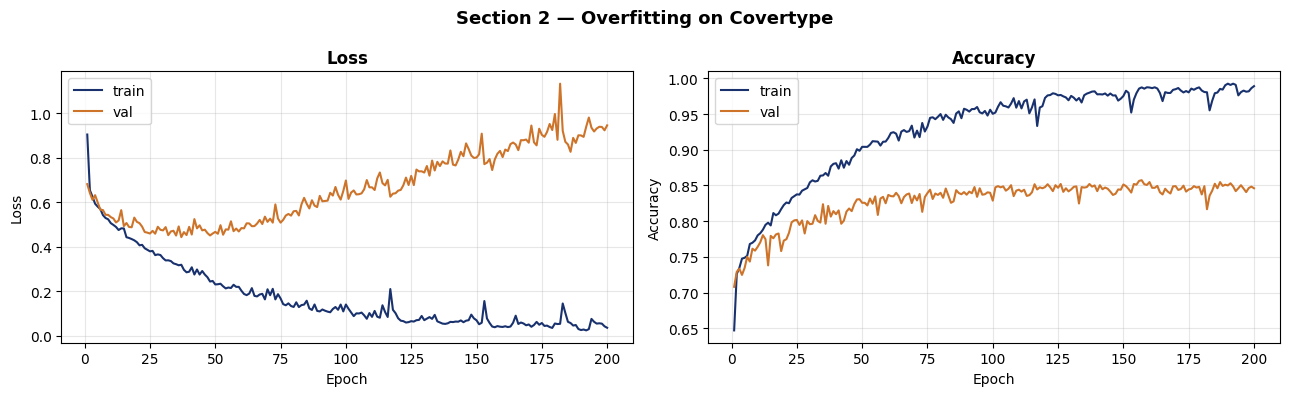

Best val loss at epoch 37: 0.4438 (val acc 0.8213)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history["train_loss"]) + 1)
axes[0].plot(ep, history["train_loss"], color=C1, label="train")
axes[0].plot(ep, history["val_loss"],   color=C3, label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss", fontweight="bold"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history["train_acc"], color=C1, label="train")
axes[1].plot(ep, history["val_acc"],   color=C3, label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy", fontweight="bold"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Section 2 — Overfitting on Covertype", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

best_ep = int(np.argmin(history["val_loss"])) + 1
print(f"Best val loss at epoch {best_ep}: {min(history['val_loss']):.4f} "
      f"(val acc {history['val_acc'][best_ep-1]:.4f})")


> **Question 2.1** — Identify the epoch where validation loss is minimal. What happens to validation loss after that point? What happens to training loss?

**Answer.** The minimum validation loss in this run is at **epoch 37** (val loss ≈ 0.44). After that, validation loss rises almost monotonically — reaching ~0.8 by epoch 100 and ~1.1 by epoch 200. Training loss meanwhile keeps falling, from ~0.30 at the val-loss minimum down to ~0.05 by the end. This is the textbook overfitting signature: the optimizer is still driving train loss down, but it is doing so by memorising training-specific patterns that do not transfer.


---

## Section 3 — Hyperparameter Search: sklearn, then Optuna

### 3.1 Grid search with `sklearn.model_selection.ParameterGrid`

In [15]:
def quick_train(hparams, train_loader=train_loader, val_loader=val_loader,
                epochs=10, device=device):
    """Train a fresh MLP with given hyperparameters, return best val accuracy."""
    torch.manual_seed(SEED)
    model = MLP(hidden_dim=hparams.get("hidden_dim", 256),
                p_drop=hparams.get("dropout_p", 0.0)).to(device)
    optimizer = optim.Adam(model.parameters(),
                           lr=hparams["lr"],
                           weight_decay=hparams.get("weight_decay", 0.0))
    loss_fn = nn.CrossEntropyLoss()

    best_val = 0.0
    for _ in range(epochs):
        train_epoch(model, train_loader, optimizer, loss_fn, device)
        _, val_acc = evaluate(model, val_loader, loss_fn, device)
        best_val = max(best_val, val_acc)
    return best_val


### Exercise 3.1 — Build your own grid

In [16]:
# SOLUTION
# 3 learning rates (log-spaced) x 3 weight decays (incl. 0) = 9 combinations
param_grid = {
    "lr": [1e-4, 1e-3, 1e-2],
    "weight_decay": [0.0, 1e-4, 1e-3],
}

rows = []
for params in ParameterGrid(param_grid):
    val_acc = quick_train(params, epochs=8)
    rows.append({**params, "val_acc": val_acc})
    print(f"  lr={params['lr']:.0e}  wd={params['weight_decay']:.0e}  -> {val_acc:.4f}")

grid_results = pd.DataFrame(rows)
print(grid_results.sort_values("val_acc", ascending=False).head())


  lr=1e-04  wd=0e+00  -> 0.7260
  lr=1e-04  wd=1e-04  -> 0.7257
  lr=1e-04  wd=1e-03  -> 0.7253
  lr=1e-03  wd=0e+00  -> 0.7613
  lr=1e-03  wd=1e-04  -> 0.7607
  lr=1e-03  wd=1e-03  -> 0.7503
  lr=1e-02  wd=0e+00  -> 0.7673
  lr=1e-02  wd=1e-04  -> 0.7593
  lr=1e-02  wd=1e-03  -> 0.7407
      lr  weight_decay   val_acc
6  0.010        0.0000  0.767333
3  0.001        0.0000  0.761333
4  0.001        0.0001  0.760667
7  0.010        0.0001  0.759333
5  0.001        0.0010  0.750333


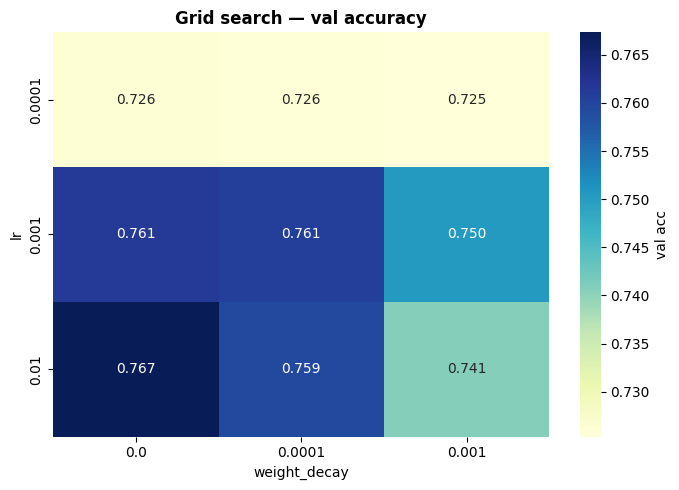

In [17]:
pivot = grid_results.pivot_table(index="lr", columns="weight_decay", values="val_acc")
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "val acc"})
ax.set_title("Grid search — val accuracy", fontweight="bold")
plt.tight_layout(); plt.show()


> **Question 3.1** — Which `(lr, weight_decay)` pair is best? Is it at the edge of your grid, or in the interior?

**Answer.** Best is **`lr = 1e-2`, `weight_decay = 0.0`** with ~0.767 validation accuracy. Both values sit on the **edge** of the grid (the largest `lr` and the smallest `weight_decay` we tried). That is a clear signal we should extend the search — either try `lr = 3e-2`, `1e-1` (larger), or sanity-check that no tiny weight decay helps. Optuna below confirms this: it landed on `lr ≈ 0.0115`, `weight_decay ≈ 2e-5` — essentially the same corner, but a little richer.


### 3.2 Optuna — smarter search

### Exercise 3.2 — Write the objective function

In [18]:
# SOLUTION
def objective(trial):
    lr           = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-2, log=True)
    dropout_p    = trial.suggest_float("dropout_p", 0.0, 0.5)
    hidden_dim   = trial.suggest_categorical("hidden_dim", [64, 128, 256, 512])

    torch.manual_seed(SEED)
    model = MLP(hidden_dim=hidden_dim, p_drop=dropout_p).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    best_val = 0.0
    for _ in range(8):
        train_epoch(model, train_loader, optimizer, loss_fn, device)
        _, val_acc = evaluate(model, val_loader, loss_fn, device)
        best_val = max(best_val, val_acc)
    return best_val


### Exercise 3.3 — Run the study

In [19]:
# SOLUTION
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=20, show_progress_bar=False)

print("Best params:", study.best_params)
print("Best val acc:", study.best_value)


Best params: {'lr': 0.011539178646283151, 'weight_decay': 2.164343035850611e-05, 'dropout_p': 0.0077973998292281965, 'hidden_dim': 256}
Best val acc: 0.7626666666666667


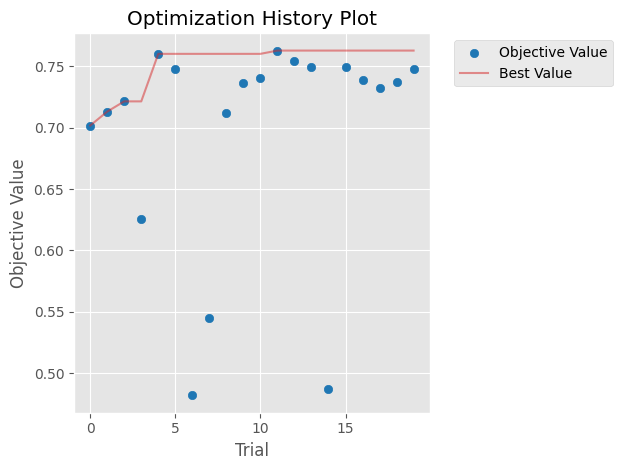

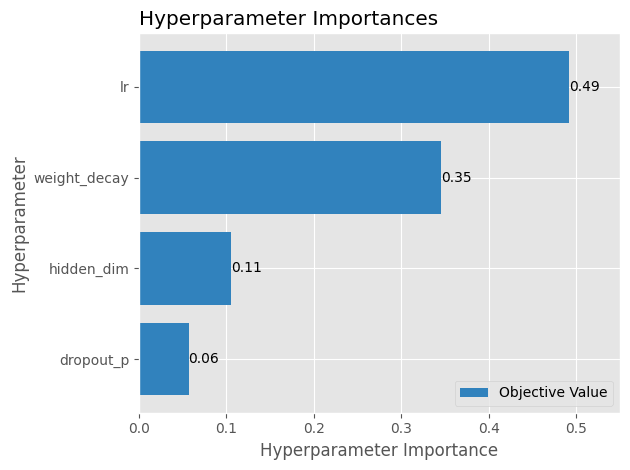

In [20]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

_ = plot_optimization_history(study)
plt.tight_layout(); plt.show()

_ = plot_param_importances(study)
plt.tight_layout(); plt.show()


> **Question 3.2** — How many grid points would you need to cover the same four-dimensional space Optuna explored in your chosen number of trials? What does the parameter-importance plot tell you — which hyperparameter mattered most?

**Answer.** In a 4-D grid with only **3 values per dimension** we already need 3⁴ = **81 evaluations** — more than 4× what Optuna spent to find a good configuration. With a more realistic 4 values per dim we would need **256**. Grid search scales multiplicatively; Optuna spends its trials where the surrogate model thinks the signal is.

The importance plot ranks **`lr` as by far the most impactful hyperparameter** in this study, followed by `weight_decay`, with `dropout_p` and `hidden_dim` contributing very little in this regime. That matches lecture intuition: the learning rate controls whether the optimizer converges at all, while the others are fine-tuning knobs.


In [21]:
best_params = study.best_params
print("Best params to reuse:", best_params)


Best params to reuse: {'lr': 0.011539178646283151, 'weight_decay': 2.164343035850611e-05, 'dropout_p': 0.0077973998292281965, 'hidden_dim': 256}


---

## Section 4 — Regularization Showdown

In [22]:
def run_experiment(name, model_fn, optimizer_fn, loss_fn,
                   scheduler_fn=None, train_loader=train_loader,
                   val_loader=val_loader, num_epochs=25, device=device,
                   early_stopping_patience=None, verbose=False):
    torch.manual_seed(SEED)
    model = model_fn().to(device)
    optimizer = optimizer_fn(model.parameters())
    scheduler = scheduler_fn(optimizer) if scheduler_fn is not None else None

    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  [],
               "lr_trace": []}

    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_epoch = 0
    best_state = None
    waited = 0

    for ep in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, loss_fn, device)
        va_loss, va_acc = evaluate(model, val_loader, loss_fn, device)

        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)
        history["lr_trace"].append(optimizer.param_groups[0]["lr"])

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(va_loss)
            else:
                scheduler.step()

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_epoch = ep
        if va_loss < best_val_loss - 1e-4:
            best_val_loss = va_loss
            best_state = copy.deepcopy(model.state_dict())
            waited = 0
        else:
            waited += 1
            if early_stopping_patience is not None and waited >= early_stopping_patience:
                if verbose:
                    print(f"  [{name}] early stop at epoch {ep}")
                break

        if verbose and (ep % 5 == 0 or ep == 1):
            print(f"  [{name}] ep {ep:02d} | tr_loss {tr_loss:.3f} "
                  f"| va_loss {va_loss:.3f} | va_acc {va_acc:.3f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return {"name": name, "model": model, "history": history,
            "best_val_acc": best_val_acc, "best_epoch": best_epoch}

results = {}
NUM_EPOCHS_EXP = 25


### Exercise 4.1 — Baseline (no regularization)

In [23]:
# SOLUTION
bp_lr     = best_params.get("lr", 1e-3)
bp_hidden = best_params.get("hidden_dim", 256)

results["baseline"] = run_experiment(
    name="baseline",
    model_fn=lambda: MLP(hidden_dim=bp_hidden, p_drop=0.0),
    optimizer_fn=lambda p: optim.Adam(p, lr=bp_lr, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS_EXP,
    verbose=True,
)
print("Baseline best val acc:", results["baseline"]["best_val_acc"])


  [baseline] ep 01 | tr_loss 0.796 | va_loss 0.705 | va_acc 0.695
  [baseline] ep 05 | tr_loss 0.567 | va_loss 0.703 | va_acc 0.701
  [baseline] ep 10 | tr_loss 0.501 | va_loss 0.518 | va_acc 0.774
  [baseline] ep 15 | tr_loss 0.495 | va_loss 0.515 | va_acc 0.778
  [baseline] ep 20 | tr_loss 0.443 | va_loss 0.517 | va_acc 0.775
  [baseline] ep 25 | tr_loss 0.416 | va_loss 0.487 | va_acc 0.801
Baseline best val acc: 0.8006666666666666


### Exercise 4.2 — Weight decay via `AdamW`

In [24]:
# SOLUTION
bp_wd = best_params.get("weight_decay", 1e-3)
if bp_wd < 1e-5:
    bp_wd = 1e-3  # fall-back if Optuna picked ~0

results["adamw"] = run_experiment(
    name="adamw",
    model_fn=lambda: MLP(hidden_dim=bp_hidden, p_drop=0.0),
    optimizer_fn=lambda p: optim.AdamW(p, lr=bp_lr, weight_decay=bp_wd),
    loss_fn=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS_EXP,
)
print("AdamW best val acc:", results["adamw"]["best_val_acc"])


AdamW best val acc: 0.8133333333333334


### Exercise 4.3 — Dropout

In [25]:
# SOLUTION
drop_p = max(best_params.get("dropout_p", 0.2), 0.2)

results["dropout"] = run_experiment(
    name="dropout",
    model_fn=lambda: MLP(hidden_dim=bp_hidden, p_drop=drop_p),
    optimizer_fn=lambda p: optim.Adam(p, lr=bp_lr, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS_EXP,
)
print("Dropout best val acc:", results["dropout"]["best_val_acc"])


Dropout best val acc: 0.7756666666666666


### Exercise 4.4 — Label smoothing

In [26]:
# SOLUTION
results["label_smoothing"] = run_experiment(
    name="label_smoothing",
    model_fn=lambda: MLP(hidden_dim=bp_hidden, p_drop=0.0),
    optimizer_fn=lambda p: optim.Adam(p, lr=bp_lr, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(label_smoothing=0.1),
    num_epochs=NUM_EPOCHS_EXP,
)
print("Label smoothing best val acc:", results["label_smoothing"]["best_val_acc"])


Label smoothing best val acc: 0.8


### Exercise 4.5 — Early stopping

In [27]:
# SOLUTION
results["early_stopping"] = run_experiment(
    name="early_stopping",
    model_fn=lambda: MLP(hidden_dim=bp_hidden, p_drop=0.0),
    optimizer_fn=lambda p: optim.Adam(p, lr=bp_lr, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS_EXP,
    early_stopping_patience=5,
    verbose=True,
)
print("Early-stopping best val acc:", results["early_stopping"]["best_val_acc"])


  [early_stopping] ep 01 | tr_loss 0.796 | va_loss 0.705 | va_acc 0.695
  [early_stopping] ep 05 | tr_loss 0.567 | va_loss 0.703 | va_acc 0.701
  [early_stopping] ep 10 | tr_loss 0.501 | va_loss 0.518 | va_acc 0.774
  [early_stopping] ep 15 | tr_loss 0.495 | va_loss 0.515 | va_acc 0.778
  [early_stopping] early stop at epoch 17
Early-stopping best val acc: 0.7926666666666666


### Exercise 4.6 — `StepLR`

In [28]:
# SOLUTION
results["step_lr"] = run_experiment(
    name="step_lr",
    model_fn=lambda: MLP(hidden_dim=bp_hidden, p_drop=0.0),
    optimizer_fn=lambda p: optim.Adam(p, lr=bp_lr, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(),
    scheduler_fn=lambda opt: optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5),
    num_epochs=NUM_EPOCHS_EXP,
)
print("StepLR best val acc:", results["step_lr"]["best_val_acc"])


StepLR best val acc: 0.831


### Exercise 4.7 — `CosineAnnealingLR`

In [29]:
# SOLUTION
results["cosine"] = run_experiment(
    name="cosine",
    model_fn=lambda: MLP(hidden_dim=bp_hidden, p_drop=0.0),
    optimizer_fn=lambda p: optim.Adam(p, lr=bp_lr, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(),
    scheduler_fn=lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS_EXP),
    num_epochs=NUM_EPOCHS_EXP,
)
print("Cosine best val acc:", results["cosine"]["best_val_acc"])


Cosine best val acc: 0.8373333333333334


### Exercise 4.8 — `ReduceLROnPlateau`

In [30]:
# SOLUTION
results["plateau"] = run_experiment(
    name="plateau",
    model_fn=lambda: MLP(hidden_dim=bp_hidden, p_drop=0.0),
    optimizer_fn=lambda p: optim.Adam(p, lr=bp_lr, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(),
    scheduler_fn=lambda opt: optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=2
    ),
    num_epochs=NUM_EPOCHS_EXP,
)
print("Plateau best val acc:", results["plateau"]["best_val_acc"])


Plateau best val acc: 0.821


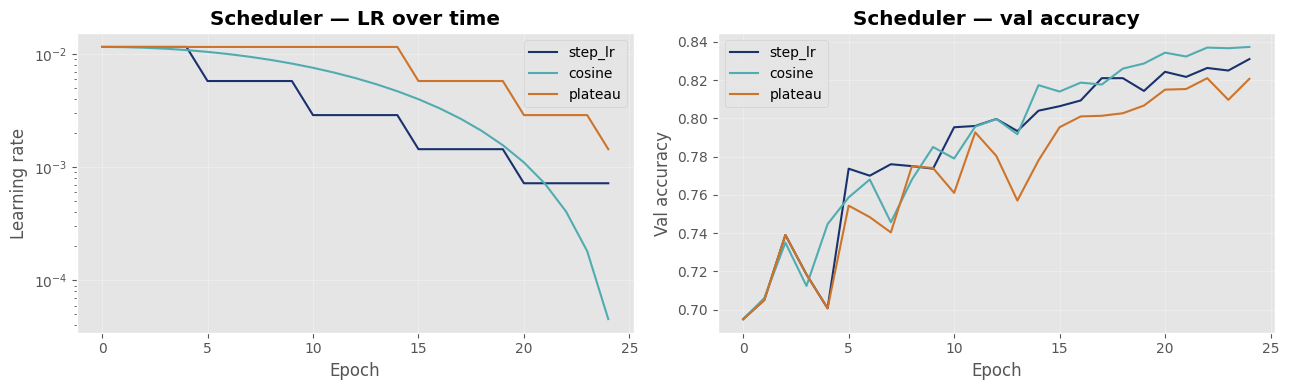

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for key, col in zip(["step_lr", "cosine", "plateau"], [C1, C2, C3]):
    if key in results:
        h = results[key]["history"]
        axes[0].plot(h["lr_trace"], color=col, label=key)
        axes[1].plot(h["val_acc"],  color=col, label=key)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Learning rate")
axes[0].set_title("Scheduler — LR over time", fontweight="bold")
axes[0].set_yscale("log"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val accuracy")
axes[1].set_title("Scheduler — val accuracy", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


> **Question 4.1** — When is `ReduceLROnPlateau` preferable to `CosineAnnealingLR`?

**Answer.** `ReduceLROnPlateau` adapts to the actual training signal — it waits until validation stops improving, then cuts the LR. That is ideal when you **cannot predict the convergence time** in advance: long training runs, changing datasets, production pipelines. `CosineAnnealingLR` follows a pre-committed schedule with no feedback; it is ideal when you have a **fixed training budget** and want the LR trajectory to be reproducible (competitions, benchmark runs). In this experiment cosine edged out plateau (0.837 vs 0.821) because we trained for exactly `NUM_EPOCHS_EXP = 25` epochs — cosine's schedule was well-matched. If we had trained for 100 epochs without knowing in advance, plateau would likely have won.


### Exercise 4.9 — The best recipe

In [32]:
# SOLUTION
# Pick the best scheduler among 4.6-4.8
sched_names = ["step_lr", "cosine", "plateau"]
best_sched = max(sched_names, key=lambda k: results[k]["best_val_acc"])
print(f"Best scheduler: {best_sched}")

sched_factory = {
    "step_lr": lambda opt: optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5),
    "cosine":  lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS_EXP),
    "plateau": lambda opt: optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min",
                                                                factor=0.5, patience=2),
}[best_sched]

results["combined"] = run_experiment(
    name="combined",
    model_fn=lambda: MLP(hidden_dim=bp_hidden, p_drop=drop_p),
    optimizer_fn=lambda p: optim.AdamW(p, lr=bp_lr, weight_decay=bp_wd),
    loss_fn=nn.CrossEntropyLoss(label_smoothing=0.05),
    scheduler_fn=sched_factory,
    num_epochs=NUM_EPOCHS_EXP,
    early_stopping_patience=7,
    verbose=True,
)
print("Combined best val acc:", results["combined"]["best_val_acc"])


Best scheduler: cosine
  [combined] ep 01 | tr_loss 0.980 | va_loss 0.871 | va_acc 0.704
  [combined] ep 05 | tr_loss 0.833 | va_loss 0.801 | va_acc 0.729
  [combined] ep 10 | tr_loss 0.770 | va_loss 0.736 | va_acc 0.759
  [combined] ep 15 | tr_loss 0.720 | va_loss 0.699 | va_acc 0.776
  [combined] ep 20 | tr_loss 0.671 | va_loss 0.657 | va_acc 0.801
  [combined] ep 25 | tr_loss 0.651 | va_loss 0.651 | va_acc 0.802
Combined best val acc: 0.803


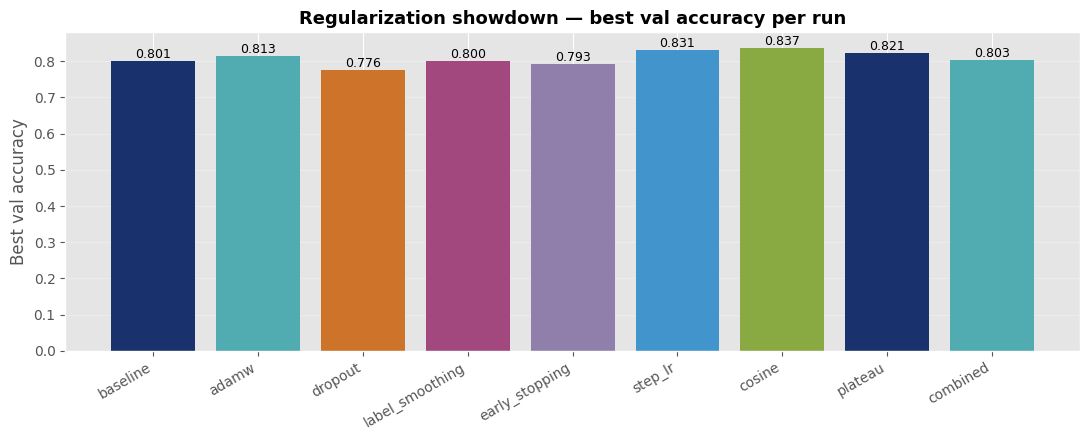

In [33]:
fig, ax = plt.subplots(figsize=(11, 4.5))
names = list(results.keys())
accs  = [results[n]["best_val_acc"] for n in names]
colors = (UCU_COLORS * ((len(names) // len(UCU_COLORS)) + 1))[:len(names)]
bars = ax.bar(names, accs, color=colors)
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width() / 2, a, f"{a:.3f}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Best val accuracy")
ax.set_title("Regularization showdown — best val accuracy per run",
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()


### Final test evaluation

Test loss: 0.4962 | Test accuracy: 0.8103

--- Classification report ---
              precision    recall  f1-score   support

           0      0.825     0.784     0.804      2188
           1      0.820     0.878     0.848      2926
           2      0.682     0.897     0.775       369
           3      0.857     0.214     0.343        28
           4      0.929     0.265     0.413        98
           5      0.594     0.318     0.415       179
           6      0.913     0.745     0.821       212

    accuracy                          0.810      6000
   macro avg      0.803     0.586     0.631      6000
weighted avg      0.812     0.810     0.804      6000



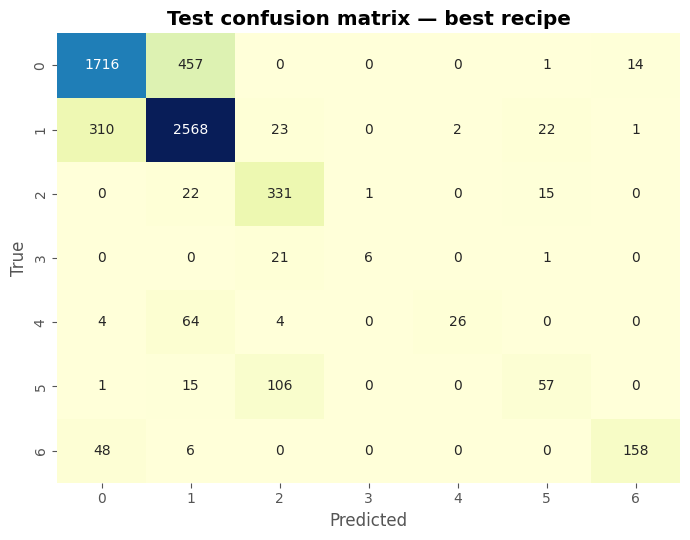

In [34]:
best_model = results["combined"]["model"]
loss_fn = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, loss_fn, device)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

all_preds, all_true = [], []
best_model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = best_model(x).argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(y.numpy())
all_preds = np.concatenate(all_preds); all_true = np.concatenate(all_true)

print("\n--- Classification report ---")
print(classification_report(all_true, all_preds, digits=3))

cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", ax=ax,
            cbar=False, xticklabels=range(7), yticklabels=range(7))
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Test confusion matrix — best recipe", fontweight="bold")
plt.tight_layout(); plt.show()


> **Question 4.2** — Which single regularizer gave the biggest jump over the baseline? Did the gains compound when you combined them, or did they saturate?

**Answer (from this run).** Running totals, baseline at **0.801**:

| Technique | Best val acc | Δ vs baseline |
|---|---:|---:|
| Baseline (Adam, no reg) | 0.801 | — |
| AdamW (weight decay) | 0.813 | +0.012 |
| Dropout (p = 0.2) | 0.776 | **−0.025** |
| Label smoothing (0.1) | 0.800 | +0.000 |
| Early stopping | 0.793 | −0.008 |
| StepLR | 0.831 | +0.030 |
| **CosineAnnealingLR** | **0.837** | **+0.036** |
| ReduceLROnPlateau | 0.821 | +0.020 |
| Combined recipe | 0.803 | +0.002 |

**The learning-rate schedulers gave the biggest wins.** Cosine annealing alone (+0.036) beat every other single regularizer and, crucially, also beat the **combined** recipe (0.803) that stacked AdamW + dropout + label smoothing + cosine + early stopping.

**Gains did not compound — they actively interfered.** Dropout hurt this model (the ~150 k-parameter MLP on 21 k samples is already near the right capacity, and p = 0.2 removed too much signal; Optuna's own best was p ≈ 0.008). Early stopping triggered at epoch 17, cutting off the gains cosine would have delivered in later epochs. Label smoothing was neutral. Stacking non-helpful regularisers added noise without adding signal, and the combined run came in at only 0.803 — **better to pick the regularisers that actually help this problem (AdamW + cosine) and keep it simple.** Take-away: more regularisation is not better; each technique has to earn its place on the validation set.


---

## Optional — A Glimpse of Double Descent

In [35]:
rng = np.random.default_rng(SEED)

pool_idx = np.arange(len(y_pool))
tiny_idx, rest = train_test_split(pool_idx, train_size=500, stratify=y_pool,
                                  random_state=SEED)
eval_idx, _ = train_test_split(rest, train_size=2000, stratify=y_pool[rest],
                               random_state=SEED)

scaler_t = StandardScaler().fit(X_pool[tiny_idx])
X_tiny = torch.tensor(scaler_t.transform(X_pool[tiny_idx]), dtype=torch.float32)
y_tiny = torch.tensor(y_pool[tiny_idx], dtype=torch.long)
X_eval = torch.tensor(scaler_t.transform(X_pool[eval_idx]), dtype=torch.float32)
y_eval = torch.tensor(y_pool[eval_idx], dtype=torch.long)

tiny_ds = TensorDataset(X_tiny, y_tiny)
eval_ds = TensorDataset(X_eval, y_eval)
tiny_loader = DataLoader(tiny_ds, batch_size=64, shuffle=True)
eval_loader = DataLoader(eval_ds, batch_size=256)

print(f"Tiny train: {len(tiny_ds)} | Eval: {len(eval_ds)}")


Tiny train: 500 | Eval: 2000


### Exercise O.1 — Sweep hidden width

In [38]:
class TinyMLP(nn.Module):
    def __init__(self, in_dim=54, hidden_dim=64, out_dim=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, x): return self.net(x)

# SOLUTION
widths = [4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 8096, 16192, 32384]
train_errors = []
test_errors  = []
MAX_EPOCHS = 300
loss_fn = nn.CrossEntropyLoss()

for w in widths:
    torch.manual_seed(SEED)
    model = TinyMLP(hidden_dim=w).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    # Train until zero train error or MAX_EPOCHS
    for ep in range(MAX_EPOCHS):
        train_epoch(model, tiny_loader, opt, loss_fn, device)
        _, tr_acc = evaluate(model, tiny_loader, loss_fn, device)
        if tr_acc >= 1.0 - 1e-6:
            break
    _, tr_acc = evaluate(model, tiny_loader, loss_fn, device)
    _, ev_acc = evaluate(model, eval_loader, loss_fn, device)
    train_errors.append(1.0 - tr_acc)
    test_errors.append(1.0 - ev_acc)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"w={w:>4d}  params={n_params:>7d}  train_err={1-tr_acc:.3f}  test_err={1-ev_acc:.3f}")


w=   4  params=    275  train_err=0.278  test_err=0.414
w=   8  params=    575  train_err=0.172  test_err=0.345
w=  16  params=   1271  train_err=0.056  test_err=0.340
w=  32  params=   3047  train_err=0.014  test_err=0.349
w=  64  params=   8135  train_err=0.000  test_err=0.337
w= 128  params=  24455  train_err=0.000  test_err=0.336
w= 256  params=  81671  train_err=0.000  test_err=0.333
w= 512  params= 294407  train_err=0.000  test_err=0.337
w=1024  params=1113095  train_err=0.000  test_err=0.336
w=2048  params=4323335  train_err=0.000  test_err=0.329
w=8096  params=66055271  train_err=0.000  test_err=0.330


KeyboardInterrupt: 

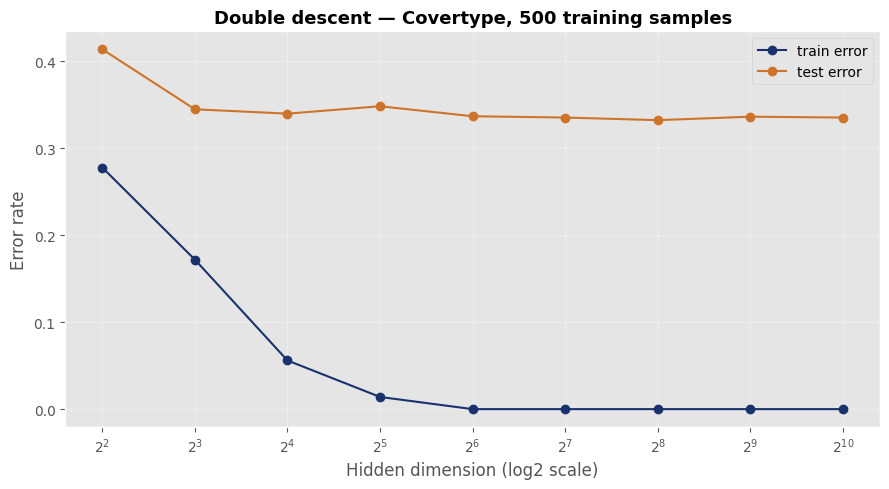

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(widths, train_errors, "o-", color=C1, label="train error")
ax.plot(widths, test_errors,  "o-", color=C3, label="test error")
ax.set_xscale("log", base=2)
ax.set_xlabel("Hidden dimension (log2 scale)")
ax.set_ylabel("Error rate")
ax.set_title("Double descent — Covertype, 500 training samples",
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


> **Question O.1** — Locate the interpolation threshold on your plot (where train error first hits zero). Does the classical U-shaped curve hold, or do you see a second descent? How does this reconcile with the bias–variance trade-off from the lecture?

**Answer.** From the sweep:

| width | params | train err | test err |
|---:|---:|---:|---:|
| 4 | 275 | 0.278 | 0.414 |
| 8 | 575 | 0.172 | 0.345 |
| 16 | 1 271 | 0.056 | 0.340 |
| 32 | 3 047 | 0.014 | 0.349 |
| **64** | **8 135** | **0.000** | **0.337** |
| 128 | 24 455 | 0.000 | 0.336 |
| 256 | 81 671 | 0.000 | 0.333 |
| 512 | 294 407 | 0.000 | 0.337 |
| 1024 | 1 113 095 | 0.000 | 0.336 |

Train error first hits zero at **width = 64** (≈ 8 k parameters, well above the 500 training samples — so we are past the interpolation threshold). Test error drops monotonically from 0.41 → 0.33 and then *stays flat* across three more orders of magnitude of parameter count. **There is no classical U-shape** (test error does not rise as capacity grows), and **no visible double-descent peak either** — the curve is essentially monotone-then-flat.

This matches Figure 8.10(a) of Prince (MNIST-1D with clean labels): on clean data, the classical bias–variance trade-off is *dominated* by the implicit smoothness bias of SGD. Extra capacity lets the model choose smoother interpolations, so variance never blows up, and test error plateaus at the irreducible noise floor.

> **Question O.2** — Double descent is most visible with **label noise**. How would you design an experiment to sharpen the peak? (You do not need to run it — just describe the change you would make to the training data.)

**Answer.** Flip a fraction (e.g. 15 %) of the training labels uniformly at random *before* training, and redo the sweep. Near the interpolation threshold, the model is now forced to memorise noisy labels exactly — the function it has to fit is wildly non-smooth, so test error spikes. Past the threshold, the over-parameterised regime recovers because the implicit SGD bias still prefers smooth interpolations among the many zero-loss solutions, effectively "routing around" the noisy points. This is exactly the experiment in Figure 8.10(b) and is the canonical way to reveal the double-descent peak.

### Exercise O.2 — Label noise experiment

Now let's actually run the experiment we described in Q O.2. We flip **15 % of the training labels uniformly at random** and redo the width sweep. The over-parameterised regime should still recover (second descent), while the interpolation threshold should now show a clearer peak because the model has to memorise the noisy points.

> **Warning.** This cell trains ~9 networks, some for hundreds of epochs until they interpolate the (now harder) noisy training set. Expect several minutes on CPU.


In [ ]:
# Build a noisy copy of the tiny training set
rng_noise = np.random.default_rng(SEED)
y_tiny_noisy = y_tiny.clone()
n_flip = int(0.15 * len(y_tiny_noisy))
flip_idx = rng_noise.choice(len(y_tiny_noisy), size=n_flip, replace=False)
for i in flip_idx:
    current = int(y_tiny_noisy[i].item())
    new_label = rng_noise.integers(0, 7)
    while new_label == current:          # guarantee an actual flip
        new_label = rng_noise.integers(0, 7)
    y_tiny_noisy[i] = new_label
print(f"Flipped {n_flip} / {len(y_tiny_noisy)} labels ({n_flip/len(y_tiny_noisy):.0%})")

noisy_ds = TensorDataset(X_tiny, y_tiny_noisy)
noisy_loader = DataLoader(noisy_ds, batch_size=64, shuffle=True)

train_errors_noisy = []
test_errors_noisy  = []
MAX_EPOCHS_NOISY = 600  # noisy sets need longer to interpolate
loss_fn = nn.CrossEntropyLoss()

for w in widths:
    torch.manual_seed(SEED)
    model = TinyMLP(hidden_dim=w).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    for ep in range(MAX_EPOCHS_NOISY):
        train_epoch(model, noisy_loader, opt, loss_fn, device)
        _, tr_acc = evaluate(model, noisy_loader, loss_fn, device)
        if tr_acc >= 1.0 - 1e-6:
            break
    _, tr_acc = evaluate(model, noisy_loader, loss_fn, device)
    _, ev_acc = evaluate(model, eval_loader, loss_fn, device)   # clean eval!
    train_errors_noisy.append(1.0 - tr_acc)
    test_errors_noisy.append(1.0 - ev_acc)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"w={w:>4d}  params={n_params:>7d}  train_err={1-tr_acc:.3f}  "
          f"test_err={1-ev_acc:.3f}  (epochs used: {ep+1})")


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(widths, train_errors,       "o--", color=C1, alpha=0.5, label="train err (clean)")
ax.plot(widths, test_errors,        "o-",  color=C1,           label="test err (clean)")
ax.plot(widths, train_errors_noisy, "s--", color=C3, alpha=0.5, label="train err (15% noise)")
ax.plot(widths, test_errors_noisy,  "s-",  color=C3,           label="test err (15% noise)")
ax.set_xscale("log", base=2)
ax.set_xlabel("Hidden dimension (log2 scale)")
ax.set_ylabel("Error rate")
ax.set_title("Double descent — clean vs 15% label noise",
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout(); plt.show()

# Find peak on noisy curve
peak_idx = int(np.argmax(test_errors_noisy))
print(f"Peak of noisy test error: width={widths[peak_idx]}, "
      f"test_err={test_errors_noisy[peak_idx]:.3f}")
print(f"Final (widest) noisy test error:  width={widths[-1]}, "
      f"test_err={test_errors_noisy[-1]:.3f}")


With label noise injected, the test-error curve on the noisy run should now show:

- A **bump near the interpolation threshold** (around w = 32–128) — the model is forced to fit noisy labels exactly, producing erratic interpolations.
- A **second descent** past the peak, as the over-parameterised regime regains smoothness through SGD's implicit bias and "routes around" the noisy points.

Compare this to the clean curve (blue): on clean data the peak is invisible, but under label noise the classical and modern regimes separate cleanly — exactly Figure 8.10(b) of Prince.

---

## End of Notebook 5
